In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_csv("Sample-Superstore.csv")

## 1 Understand Dataset

In [7]:
df.head()

,csvbase_row_id,﻿Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   csvbase_row_id  9994 non-null   int64  
 1   ﻿Row ID         9994 non-null   int64  
 2   Order ID        9994 non-null   str    
 3   Order Date      9994 non-null   str    
 4   Ship Date       9994 non-null   str    
 5   Ship Mode       9994 non-null   str    
 6   Customer ID     9994 non-null   str    
 7   Customer Name   9994 non-null   str    
 8   Segment         9994 non-null   str    
 9   Country         9994 non-null   str    
 10  City            9994 non-null   str    
 11  State           9994 non-null   str    
 12  Postal Code     9994 non-null   int64  
 13  Region          9994 non-null   str    
 14  Product ID      9994 non-null   str    
 15  Category        9994 non-null   str    
 16  Sub-Category    9994 non-null   str    
 17  Product Name    9994 non-null   str    
 18 

In [9]:
df.describe()


,csvbase_row_id,﻿Row ID,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,4997.500000,4997.500000,55190.379428,229.858001,3.789574,0.156203,28.656896
std,2885.163629,2885.163629,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1.000000,1.000000,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,2499.250000,2499.250000,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,4997.500000,4997.500000,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,7495.750000,7495.750000,90008.000000,209.940000,5.000000,0.200000,29.364000
max,9994.000000,9994.000000,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [10]:
df.shape

(9994, 22)

In [11]:
df.columns

Index(['csvbase_row_id', '﻿Row ID', 'Order ID', 'Order Date', 'Ship Date',
       'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country',
       'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='str')

## 2 Data Clening

In [21]:
df.isnull().sum()

csvbase_row_id    0
﻿Row ID           0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [24]:
Q1=df["Sales"].quantile(0.25)
Q3=df["Sales"].quantile(0.75)

IQR=Q3-Q1

df=df[(df["Sales"]>=Q1-1.5*IQR) &
      (df["Sales"]<=Q3+1.5*IQR)]

In [26]:
df.to_csv("Sample-Superstore.csv",index=False)

## 3 EDA Visualizations

(array([4859., 1370.,  674.,  488.,  399.,  287.,  256.,  196.,  145.,
         153.]),
 array([4.440000e-01, 5.022560e+01, 1.000072e+02, 1.497888e+02,
        1.995704e+02, 2.493520e+02, 2.991336e+02, 3.489152e+02,
        3.986968e+02, 4.484784e+02, 4.982600e+02]),
 <BarContainer object of 10 artists>)

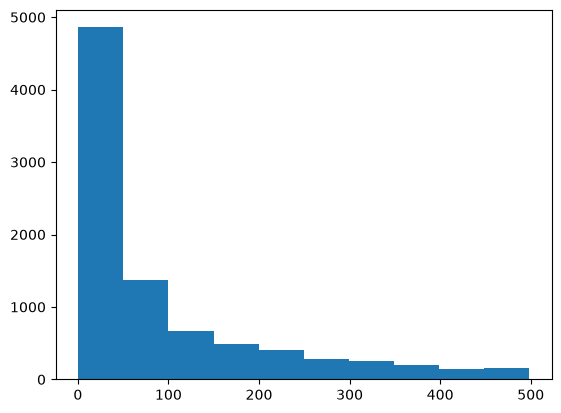

In [27]:
plt.hist(df["Sales"])

<Axes: ylabel='Sales'>

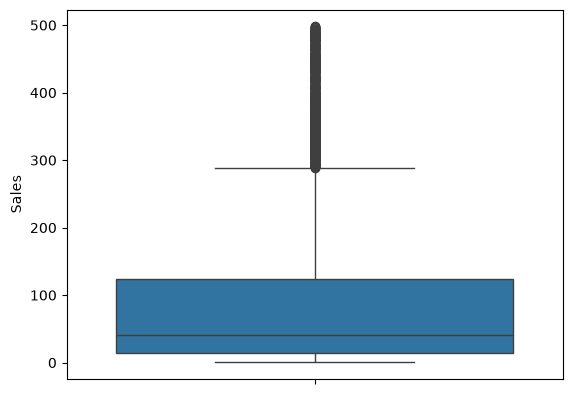

In [28]:
sns.boxplot(df["Sales"])

<Axes: xlabel='Category', ylabel='count'>

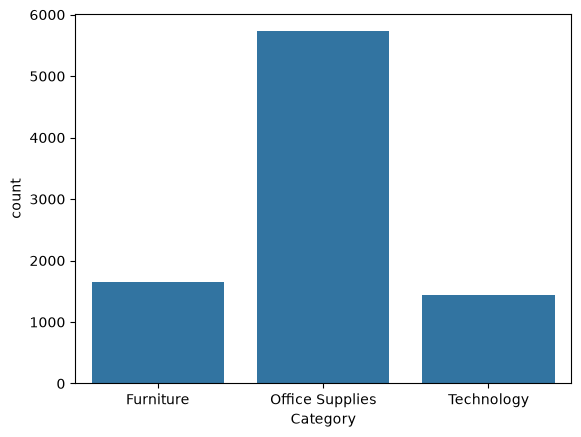

In [29]:
sns.countplot(x="Category",data=df)

<Axes: >

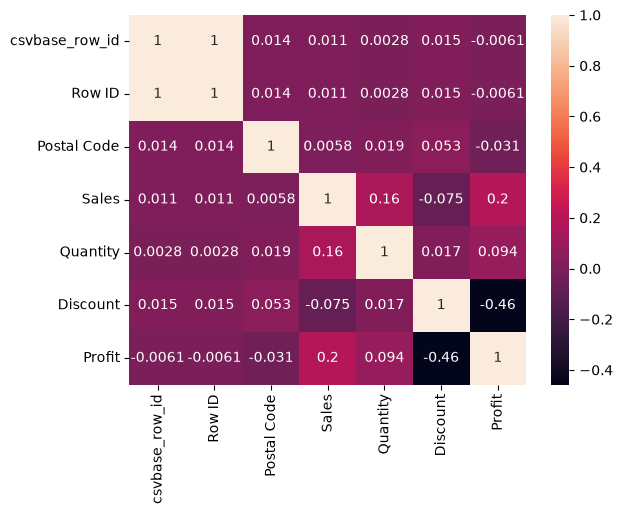

In [30]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

<Axes: xlabel='Order Date'>

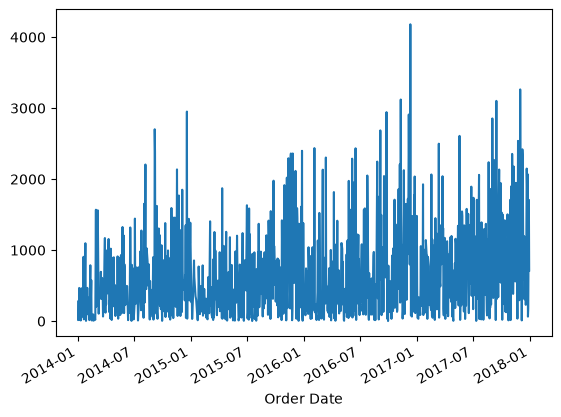

In [31]:
sales=df.groupby("Order Date")["Sales"].sum()

sales.plot()

## Key Insights

1. Technology category has highest sales.

2. West region generated highest revenue.

3. Furniture has lower profit.

4. November has maximum sales.

5. Discount negatively affects profit.